In [1]:
import struct
import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pyvista

# plt.rcParams['figure.figsize']=(12,12)
# plt.rcParams['font.weight']='bold'
# plt.rcParams['axes.labelweight']='bold'
# plt.rcParams['lines.linewidth']=2
# plt.rcParams['lines.markeredgewidth']=2
# %matplotlib inline
# %config InlineBackend.figure_format = "retina"

In [2]:
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.ThinCurr import ThinCurr
# from OpenFUSIONToolkit.ThinCurr.sensor import Mirnov, save_sensors
# from OpenFUSIONToolkit.util import mu0
# from OpenFUSIONToolkit.io import histfile

In [3]:
hdf5_file_path = 'tokamak_mesh_EHL2_holes.h5'
curr_file_path = 'Central_Solenoid_Current.txt'
xml_file_path  = 'oft_in.xml'

def print_h5_tree(group, indent=0):
    for key in group.keys():
        item = group[key]
        if isinstance(item, h5py.Dataset):
            print(' ' * indent + f"├── {key} (Dataset) {item.shape} {item.dtype}")
        elif isinstance(item, h5py.Group):
            print(' ' * indent + f"├── {key} (Group)")
            print_h5_tree(item, indent + 4)
with h5py.File(hdf5_file_path, 'r') as h5_file:
    print("HDF5 file tree structure:")
    print_h5_tree(h5_file)

HDF5 file tree structure:
├── mesh (Group)
    ├── LC (Dataset) (40652, 3) int32
    ├── NODESET0001 (Dataset) (12,) int32
    ├── NODESET0002 (Dataset) (12,) int32
    ├── NODESET0003 (Dataset) (12,) int32
    ├── NODESET0004 (Dataset) (12,) int32
    ├── NODESET0005 (Dataset) (18,) int32
    ├── NODESET0006 (Dataset) (22,) int32
    ├── NODESET0007 (Dataset) (22,) int32
    ├── NODESET0008 (Dataset) (18,) int32
    ├── NODESET0009 (Dataset) (22,) int32
    ├── NODESET0010 (Dataset) (12,) int32
    ├── NODESET0011 (Dataset) (12,) int32
    ├── NODESET0012 (Dataset) (12,) int32
    ├── NODESET0013 (Dataset) (12,) int32
    ├── NODESET0014 (Dataset) (22,) int32
    ├── NODESET0015 (Dataset) (22,) int32
    ├── NODESET0016 (Dataset) (18,) int32
    ├── NODESET0017 (Dataset) (22,) int32
    ├── NODESET0018 (Dataset) (22,) int32
    ├── NODESET0019 (Dataset) (18,) int32
    ├── NODESET0020 (Dataset) (22,) int32
    ├── NODESET0021 (Dataset) (22,) int32
    ├── NODESET0022 (Dataset) (22,) i

In [4]:
from pathlib import Path
from typing import List, Tuple
def load_time_current_txt(path: str) -> Tuple[List[float], List[float]]:
    """Load time (ms) and current (A) from a plain text file."""
    times_ms: List[float] = []
    currents_a: List[float] = []
    
    # 将字符串路径转换为 Path 对象
    path_obj = Path(path)
    with path_obj.open("r", encoding="utf-8") as f:
        for line in f:
            stripped = line.strip()
            if not stripped:
                continue
            # Skip header or comment lines
            if stripped.startswith("#") or "Time" in stripped or "Current" in stripped:
                continue

            parts = stripped.split()
            if len(parts) < 2:
                continue

            try:
                t_ms = float(parts[0])
                I_a = float(parts[1])
            except ValueError:
                # Non-numeric line, skip
                continue

            times_ms.append(t_ms)
            currents_a.append(I_a)

    if not times_ms:
        raise ValueError(f"No valid data lines found in {path}")

    return times_ms, currents_a

In [5]:
times_ms, currents_a = load_time_current_txt(curr_file_path)
print(np.shape(times_ms))
print(np.shape(currents_a))


(3301,)
(3301,)


Text(0.5, 1.0, 'Central Solenoid Current')

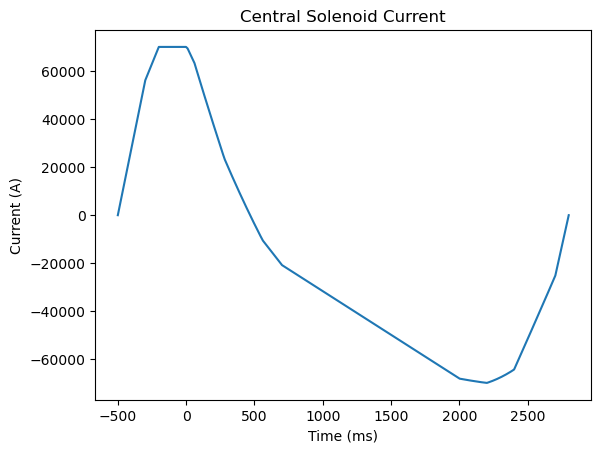

In [6]:
ax, fig = plt.subplots()
fig.plot(times_ms, currents_a)
fig.set_xlabel('Time (ms)')
fig.set_ylabel('Current (A)')
fig.set_title('Central Solenoid Current')

In [7]:
myOFT = OFT_env(nthreads=28)
tw_torus = ThinCurr(myOFT)
tw_torus.setup_model(mesh_file=hdf5_file_path,xml_filename=xml_file_path)
tw_torus.setup_io()

         If correct, this may significantly degrade performance due to oversubcription
#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           0bd44b1
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =   28
Fortran input file    = /tmp/oft_2148427/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


Creating thin-wall model
  No V(t) driver coils found
  Loading I(t) driver coils
    Masked      0 coils from sensors
  Building holes

  Loading region resistivity:
     1  3.7000E-05
     2  2.4670E-05
     3  5.6920E-05
     4  3.7000E-05

  Setup complete:
    # of points    =        20742
    # of edges     =        61458
    # of cells     =        40652
    # of holes     =           65
    # of closures  =            0
    #

In [8]:
# sensors = []
# for i, theta in enumerate(np.linspace(0.0,2.0*np.pi/20.0,3)):
#     print(i,theta*180.0/np.pi)
#     sensors.append(Mirnov(1.6*np.r_[np.cos(theta),np.sin(theta),0.0], np.r_[0.0,0.0,1.0], 'Bz_{0}'.format(i+1)))
# save_sensors(sensors)
# Msensor, Msc, sensor_obj = tw_torus.compute_Msensor('floops.loc')

In [9]:
Mc = tw_torus.compute_Mcoil()

Building coil<->element inductance matrices
  Time =  0s          


In [10]:
tw_torus.compute_Lmat(use_hodlr=True,cache_file='DATA_HOLDR_L.save')

 Partitioning grid for block low rank compressed operators
   nBlocks =                  32
   Avg block size =          618
   # of SVD =                210
   # of ACA =                166

 Building block low rank inductance operator
   Building hole and Vcoil columns
   Building diagonal blocks
     10%
     20%
     30%
     40%
     50%
     60%
     70%
     80%
     90%
   Building off-diagonal blocks using ACA+
     10%
     20%
     30%
     40%
     50%
     60%
     70%
     80%
     90%
     Compression ratio:   8.3%  ( 3.23E+07/ 3.91E+08)
     Time = 24s          
   Saving HODLR matrix to file: DATA_HOLDR_L.save


In [11]:
tw_torus.compute_Rmat()

Building resistivity matrix


In [12]:
dt = 1.E-3
nsteps = 3300
# coil_currs = np.array([
#     [0.0,   1.E6],
#     [4.E-3, 0.0],
#     [1.0,   0.0]
# ])
# coil_currs = np.array([
#     [0.0, 1.E6],
#     [8.E-3, 0.0],
#     [1.0, 0.0]
# ])

coil_currs = []

for i in range(len(currents_a)):
    coil_currs.append([1e-3 * i , currents_a[i]])
coil_currs = np.array(coil_currs)
# tw_torus.run_td(dt,nsteps,status_freq=10,coil_currs=coil_currs,sensor_obj=sensor_obj)

In [13]:
tw_torus.run_td(dt,nsteps,status_freq=10,plot_freq=30,coil_currs=coil_currs)


Starting time-domain simulation
  timestep    time           sol_norm     nits    solver time
      10    1.000000E-02    1.4295E-02       1        0.01
      20    2.000000E-02    2.0100E-02       5        0.04
      30    3.000000E-02    2.3782E-02       3        0.03
      40    4.000000E-02    2.6254E-02       1        0.01
      50    5.000000E-02    2.8360E-02       1        0.01
      60    6.000000E-02    2.9887E-02       1        0.01
      70    7.000000E-02    3.1251E-02       1        0.01
      80    8.000000E-02    3.2416E-02       1        0.02
      90    9.000000E-02    3.3374E-02       1        0.01
     100    1.000000E-01    3.4136E-02       1        0.01
     110    1.100000E-01    3.4719E-02       1        0.01
     120    1.200000E-01    3.5140E-02       1        0.01
     130    1.300000E-01    3.5415E-02       1        0.01
     140    1.400000E-01    3.5559E-02       1        0.01
     150    1.500000E-01    3.5584E-02       1        0.01
     160    1.600000

In [14]:
_, Bc = tw_torus.compute_Bmat(cache_file='DATA_HODLR_B.save')

 Building block low rank magnetic field operator
   Building hole and Vcoil columns
   Building diagonal blocks
     10%
     20%
     30%
     40%
     50%
     60%
     70%
     80%
     90%
   Building off-diagonal blocks using ACA+
     10%
     20%
     30%
     40%
     50%
     60%
     70%
     80%
     90%
     Compression ratio:   8.1%  ( 1.00E+08/ 1.23E+09)
     Time = 39s          
   Saving HODLR matrix from file: DATA_HODLR_B.save


In [15]:
# tw_torus.plot_td(nsteps,compute_B=True,sensor_obj=sensor_obj)
tw_torus.plot_td(nsteps,compute_B=True,plot_freq=30)
plot_data = tw_torus.build_XDMF()


Post-processing time-domain simulation

Creating output files: oft_xdmf.XXXX.h5
  Removing old Xdmf files
    Removed 0 files
  Found Group: thincurr
    Found Mesh: icoils
    Found Mesh: smesh


In [16]:
cam_position = [
    (-8, 8, 5),  # 相机位置坐标
    (0.0, 0.0, 0.0),  # 焦点坐标
    (0.0, 0.0, 1.0)  # 定义"向上"方向
]
windowsize = [1920, 1080]

pyvista.OFF_SCREEN = True  # 关键：启用离屏渲染
pyvista.start_xvfb()       # 启动虚拟显示（可选，部分场景需要）
pyvista.set_jupyter_backend('static') # Comment to enable interactive PyVista plots

/home/yfz/.conda/envs/OFT-260316/lib/python3.13/site-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(


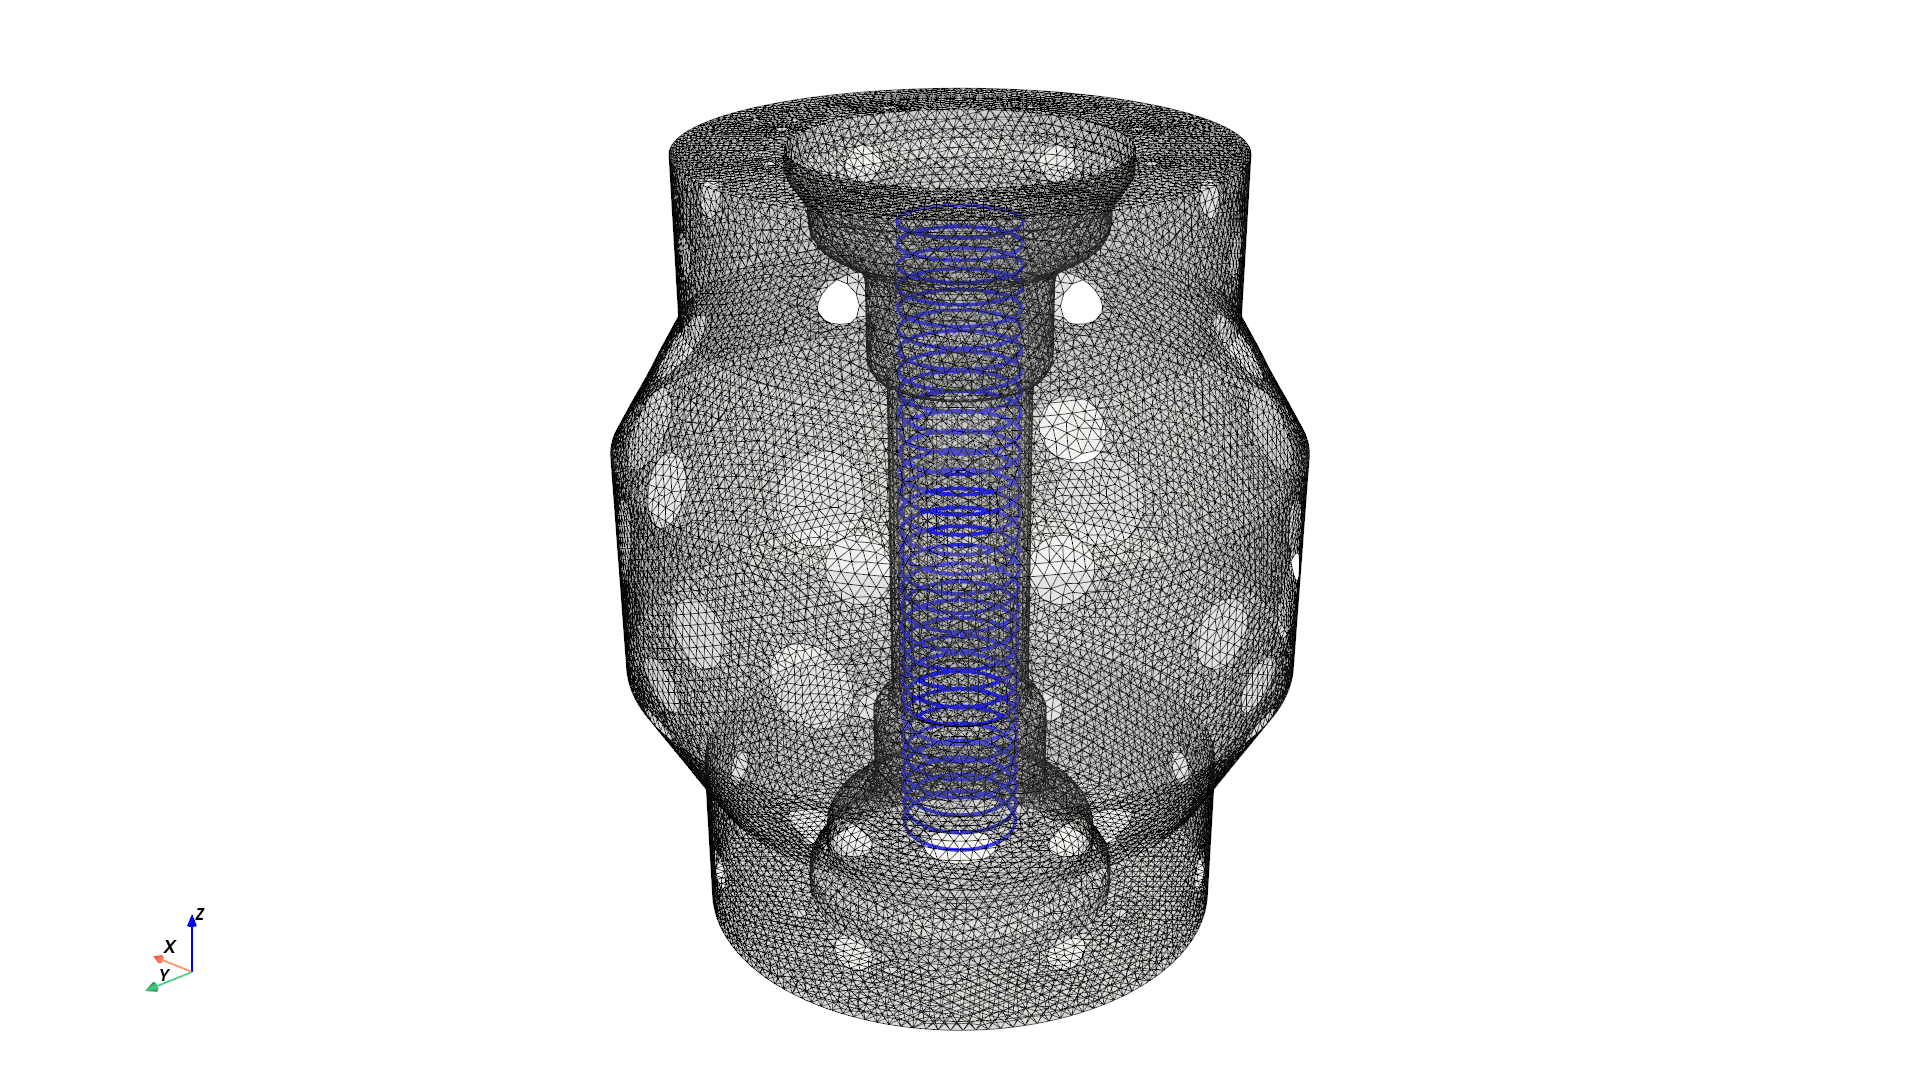

In [17]:
grid = plot_data['ThinCurr']['smesh'].get_pyvista_grid()
icoil_grid = plot_data['ThinCurr']['icoils'].get_pyvista_grid()
p = pyvista.Plotter(window_size=windowsize)
p.camera_position = cam_position
p.show_axes()
p.add_mesh(grid, color="white", opacity=0.25, show_edges=False)
p.add_mesh(grid, style="wireframe", color="black", opacity=1.0, show_edges=True, edge_opacity=1.0)
p.add_mesh(icoil_grid, color="blue", opacity=1.0, line_width=4)
# p.add_ruler(pointa=(0, -1.5, 0), pointb=(1.5, -1.5, 0), title='')
# p.add_box_axes()

p.show()

In [18]:
plot_step = 20
Jfull = plot_data['ThinCurr']['smesh'].get_field('J_v',timestep = plot_step)
Bfull = plot_data['ThinCurr']['smesh'].get_field('B_v',timestep = plot_step)
Ffull = np.zeros((np.shape(Jfull)))
print(np.shape(Ffull))
for i in range(np.shape(Jfull)[0]):
    Ffull[i,0] = Jfull[i,1] * Bfull[i,2] - Jfull[i,2] * Bfull[i,1]
    Ffull[i,1] = Jfull[i,2] * Bfull[i,0] - Jfull[i,0] * Bfull[i,2]
    Ffull[i,2] = Jfull[i,0] * Bfull[i,1] - Jfull[i,1] * Bfull[i,0] 

J_scale = 0.5 / 1e2
B_scale = 0.5 / 5e-4
F_scale = 0.25 / 2e-2


(20742, 3)


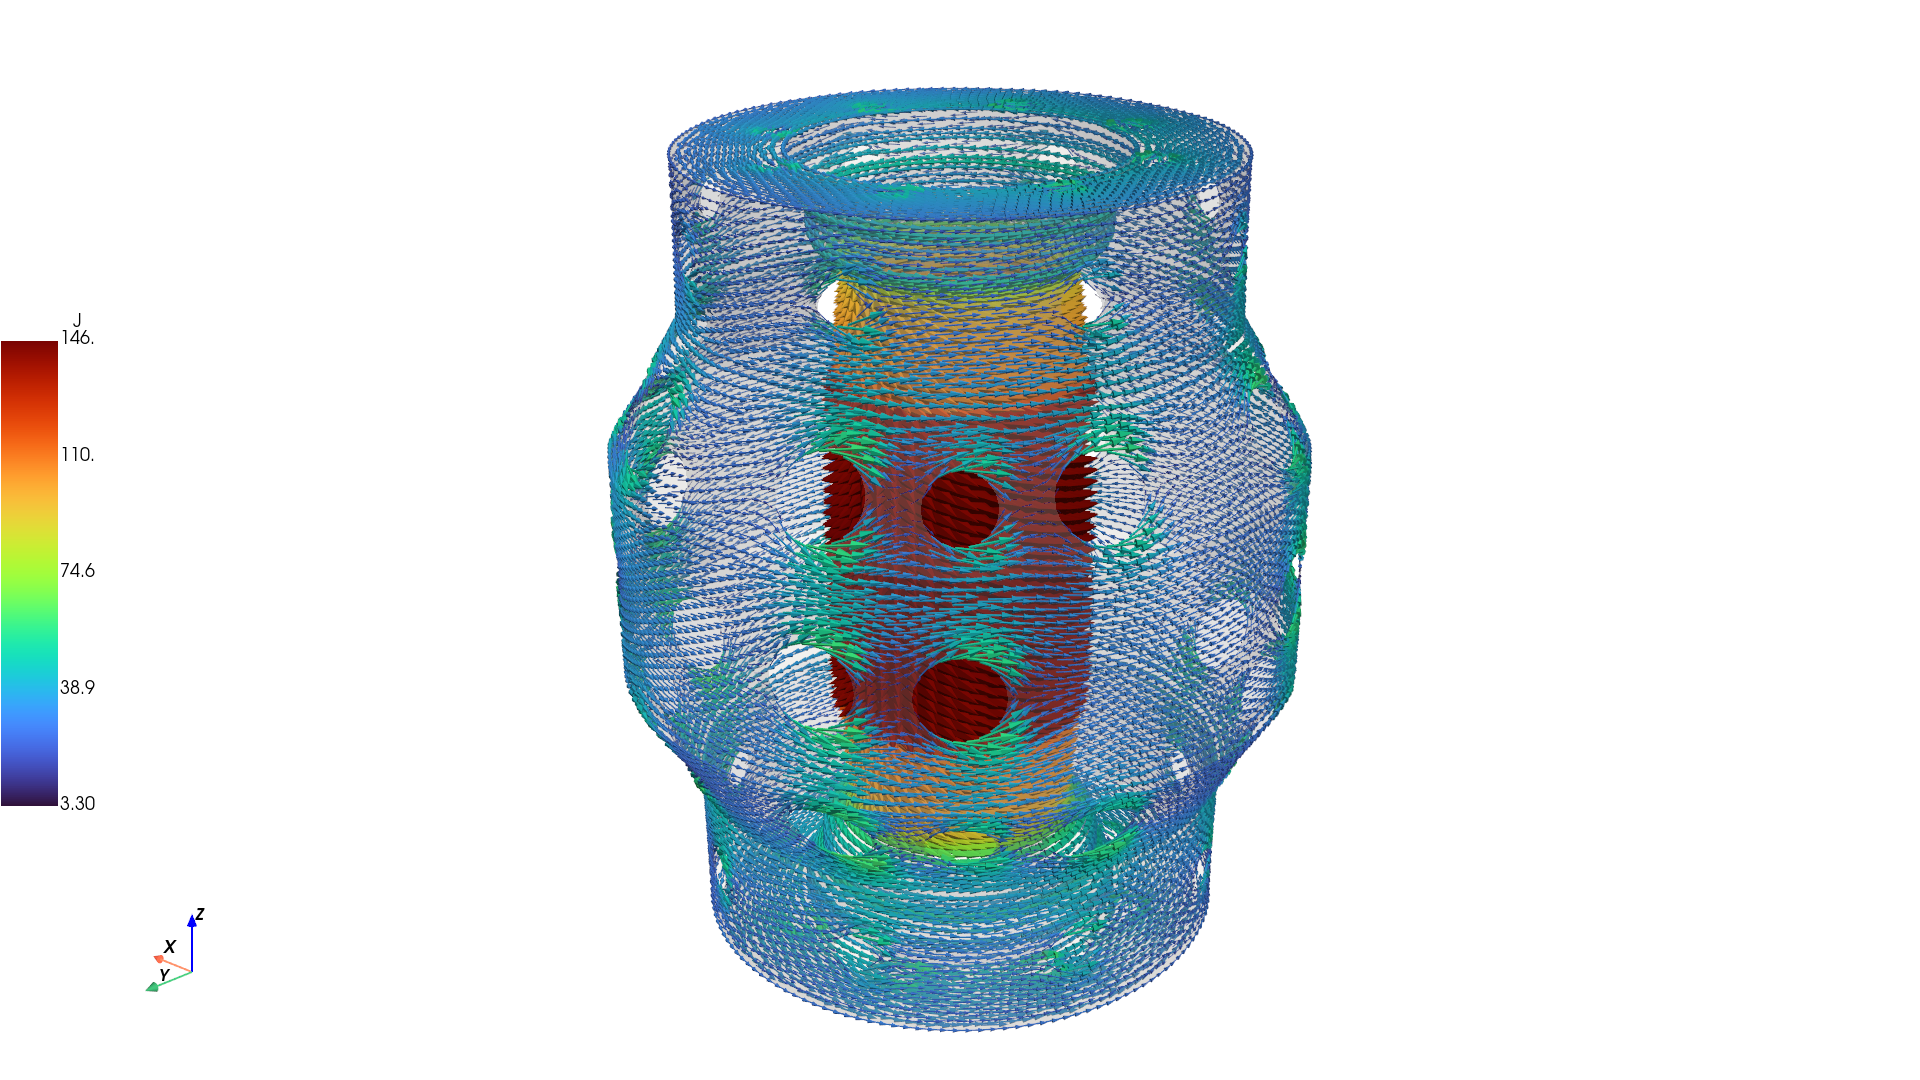

In [19]:

#
grid["vectors"] = Jfull
grid.set_active_vectors("vectors")
p = pyvista.Plotter(window_size=windowsize)
# scale = 0.25/(np.linalg.norm(Jfull,axis=1)).max()
# scale = 0.25/4e5
arrows = grid.glyph(scale="vectors", orient="vectors", factor=J_scale)
p.camera_position = cam_position
p.show_axes()
p.add_mesh(grid, color="white", opacity=0.25, show_edges=False)
# p.add_mesh(grid, style="wireframe", color="black", opacity=1.0, show_edges=True, edge_opacity=1.0)
p.add_mesh(arrows, cmap="turbo", scalar_bar_args={'title': "J", "vertical": True, "position_y":0.25, "position_x": 0.0})
p.show()

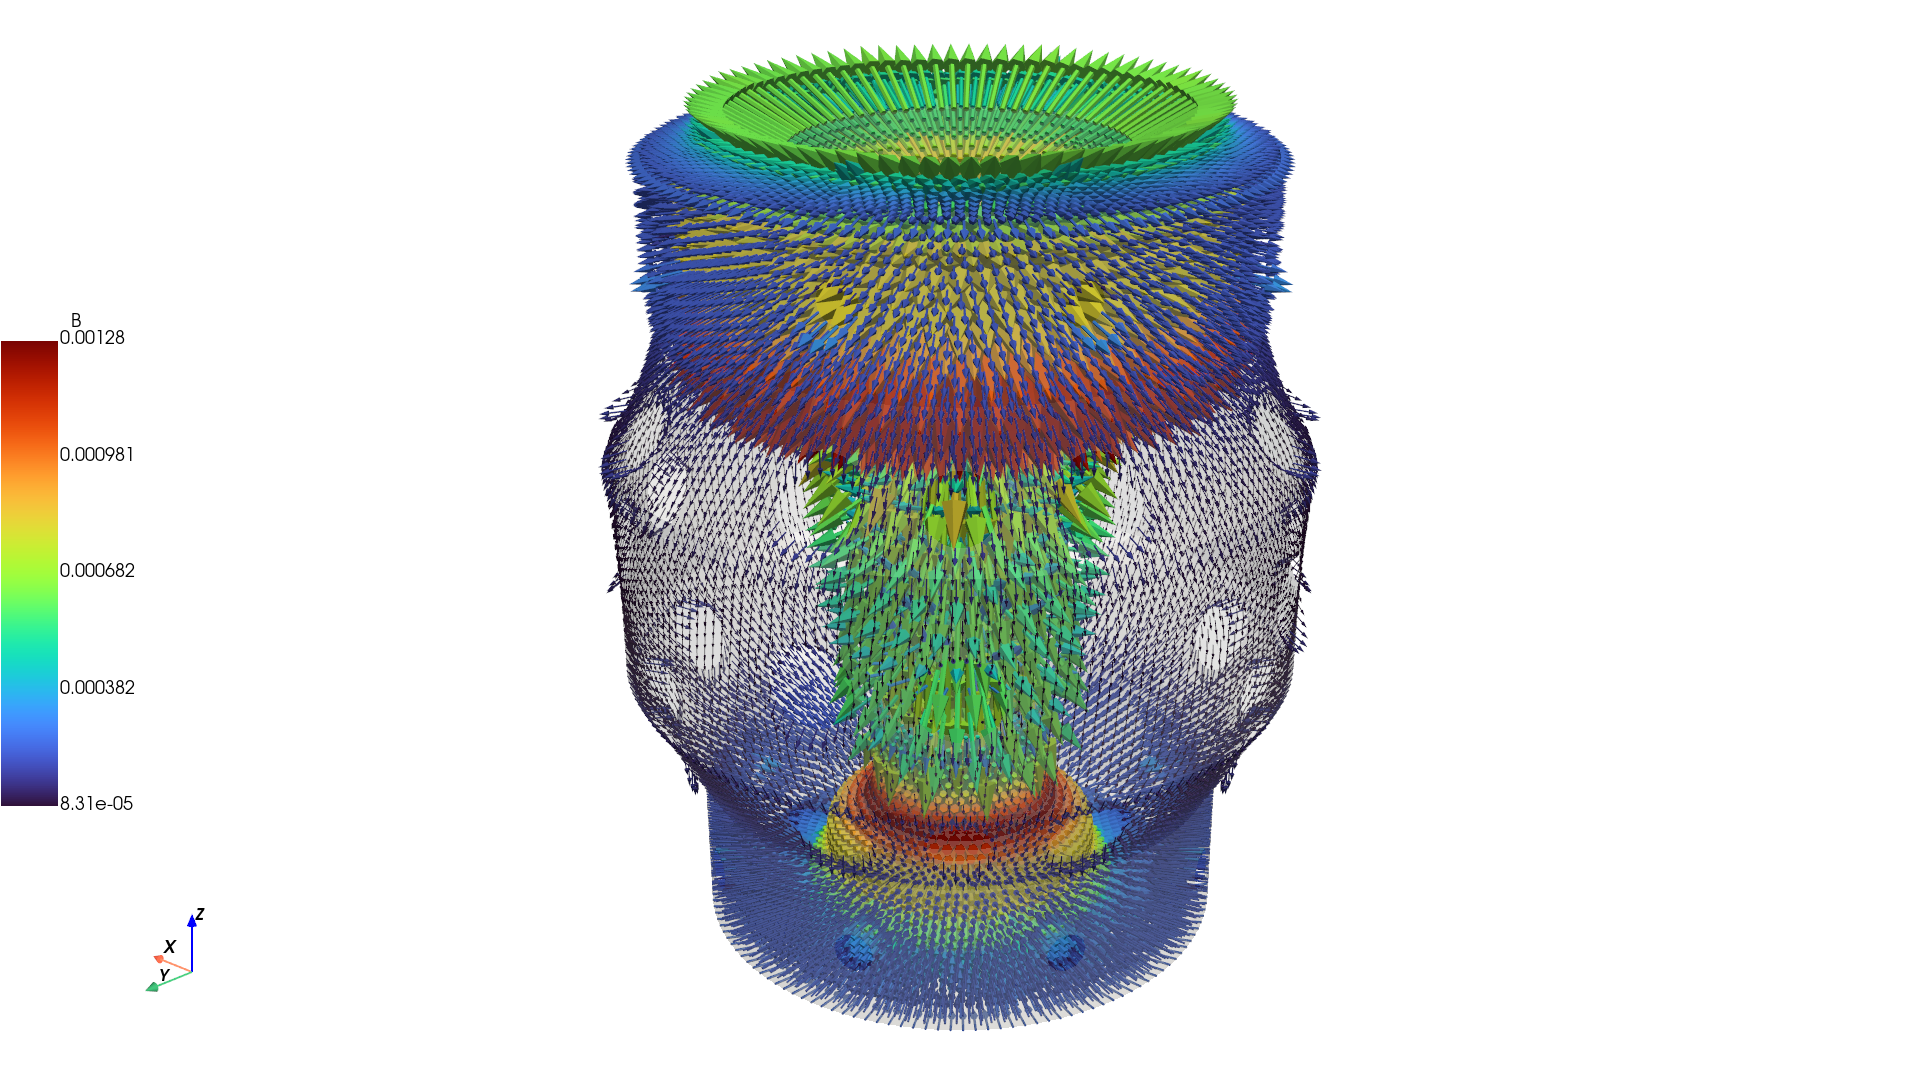

In [20]:

#
grid["vectors"] = Bfull
grid.set_active_vectors("vectors")
p = pyvista.Plotter(window_size=windowsize)
# scale = 0.25/(np.linalg.norm(Bfull,axis=1)).max()
arrows = grid.glyph(scale="vectors", orient="vectors", factor=B_scale)
p.camera_position = cam_position
p.show_axes()
p.add_mesh(grid, color="white", opacity=0.25, show_edges=False)
# p.add_mesh(grid, style="wireframe", color="black", opacity=1.0, show_edges=True, edge_opacity=1.0)
p.add_mesh(arrows, cmap="turbo", scalar_bar_args={'title': "B", "vertical": True, "position_y":0.25, "position_x": 0.0})
p.show()

In [21]:
print(np.shape(Jfull))
print(np.shape(Bfull))

(20742, 3)
(20742, 3)


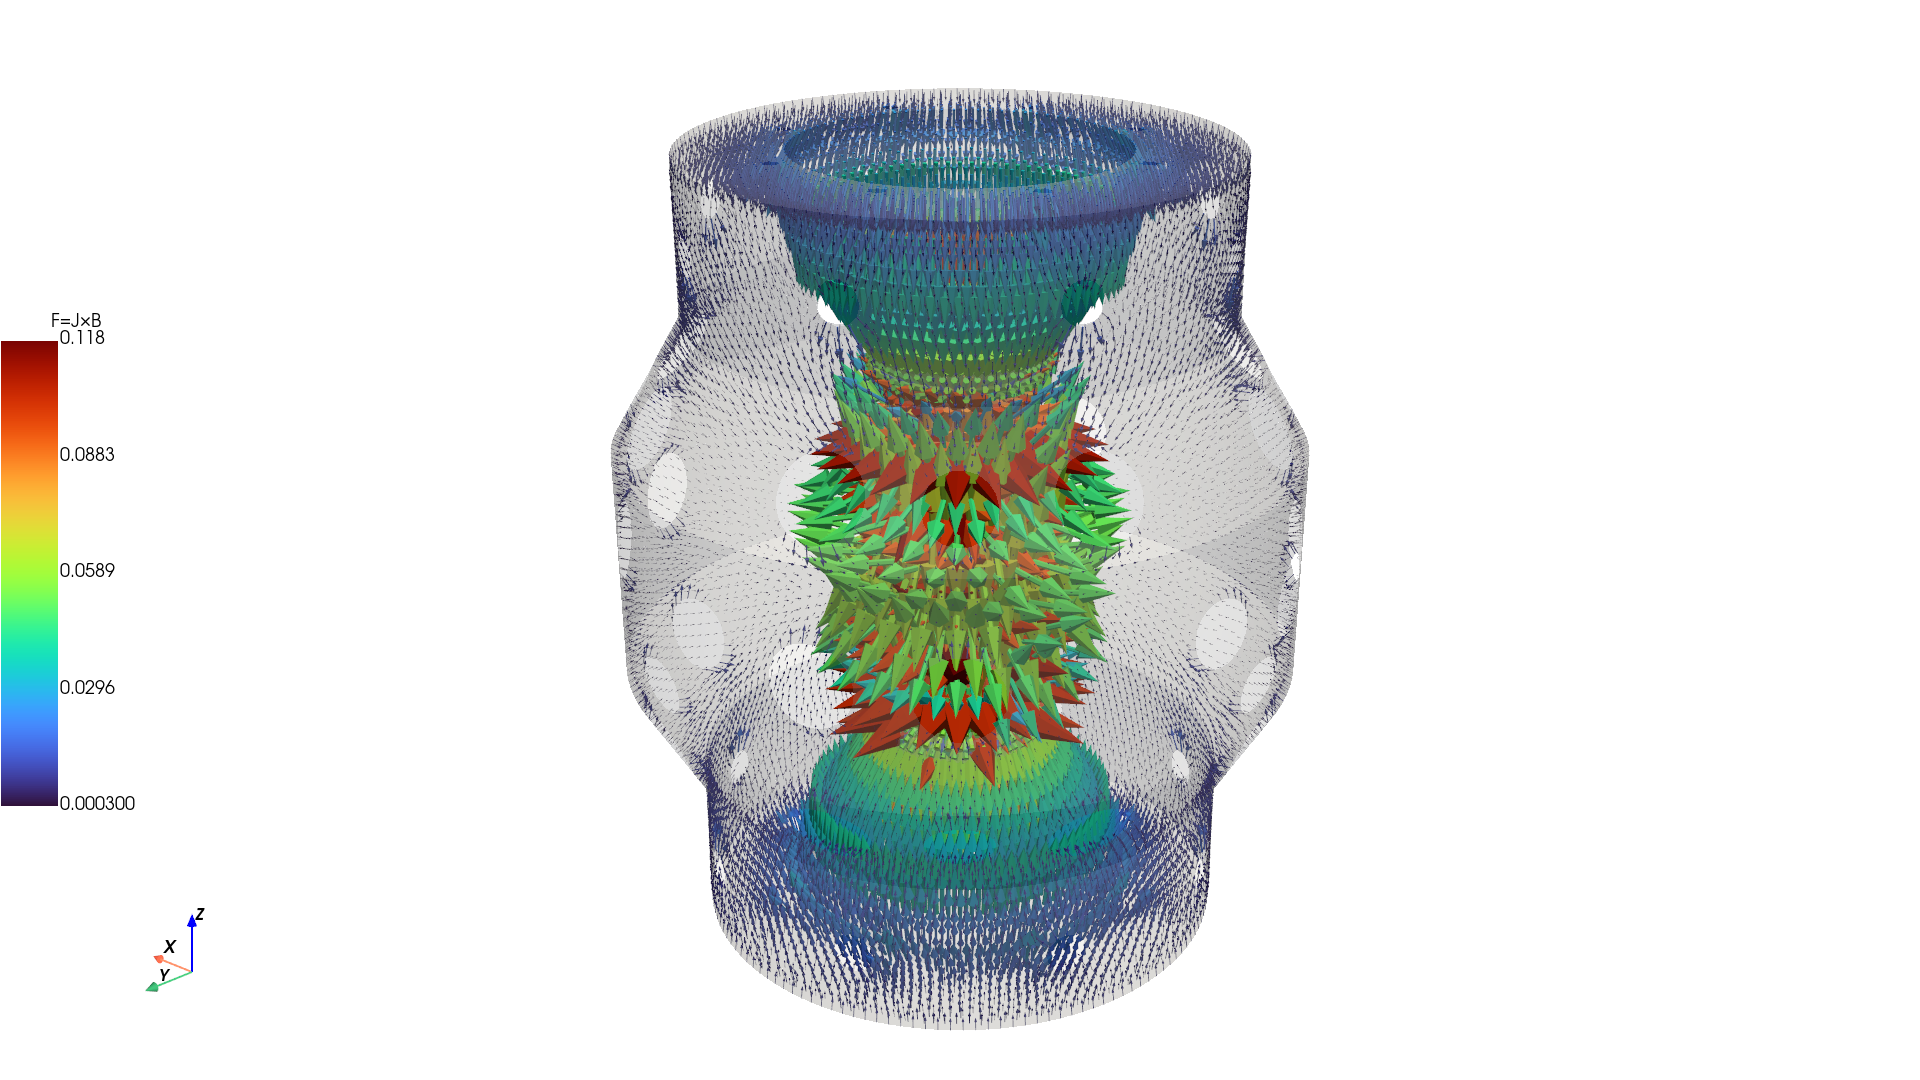

In [22]:


grid["vectors"] = Ffull
grid.set_active_vectors("vectors")
p = pyvista.Plotter(window_size=windowsize)
# scale = 0.25/(np.linalg.norm(Ffull,axis=1)).max()
arrows = grid.glyph(scale="vectors", orient="vectors", factor=F_scale)
p.camera_position = cam_position
p.show_axes()
p.add_mesh(grid, color="white", opacity=0.25, show_edges=False)
# p.add_mesh(grid, style="wireframe", color="black", opacity=1.0, show_edges=True, edge_opacity=1.0)
p.add_mesh(arrows, cmap="turbo", scalar_bar_args={'title': "F=J×B", "vertical": True, "position_y":0.25, "position_x": 0.0})
p.show()

In [23]:
# --- 手动设置统一的标量范围 (User Requirement 2) ---
# 请根据你的实际物理量级修改这些值
J_clim = [0, 3e2]   # 例如：J 的范围 0 到 2 MA/m^2
B_clim = [0, 5e-4]     # 例如：B 的范围 0 到 3 T
F_clim = [0, 2e-2]   # 例如：F 的范围

colorbar_position_x = 0.01

fig_dir = "./figs"
os.makedirs(fig_dir, exist_ok=True)

In [24]:
# ==========================================
# 3. 循环绘制
# ==========================================
start_step = 0
end_step = 110
for plot_step in range(start_step, end_step + 1):
    print(f"正在处理时间步 {plot_step}/{end_step}...")

    # 获取数据
    try:
        Jfull = plot_data['ThinCurr']['smesh'].get_field('J_v', timestep=plot_step)
        Bfull = plot_data['ThinCurr']['smesh'].get_field('B_v', timestep=plot_step)
    except Exception as e:
        print(f"获取时间步 {plot_step} 的数据失败: {e}")
        continue

    # 1. 计算 F 向量 (F = J × B)
    Ffull = np.zeros_like(Jfull)
    Ffull[:, 0] = Jfull[:, 1] * Bfull[:, 2] - Jfull[:, 2] * Bfull[:, 1]
    Ffull[:, 1] = Jfull[:, 2] * Bfull[:, 0] - Jfull[:, 0] * Bfull[:, 2]
    Ffull[:, 2] = Jfull[:, 0] * Bfull[:, 1] - Jfull[:, 1] * Bfull[:, 0]

    # 2. [新增] 计算力的大小（模长）用于热力图
    F_mag = np.linalg.norm(Ffull, axis=1)
    J_norm = np.linalg.norm(Jfull, axis=1)

    current_time = plot_step * 1e-3 * 30

    # 创建 2x2 布局
    p = pyvista.Plotter(shape=(2, 2), window_size=windowsize, off_screen=True)

    # --- 子图 1 (0,0): J (保持矢量箭头) ---
    p.subplot(0, 0)
    grid["vectors"] = Jfull
    grid.set_active_vectors("vectors")
    arrows_J = grid.glyph(scale="vectors", orient="vectors", factor=J_scale)
    max_J = np.max(J_norm)
    p.add_mesh(grid, color="white", opacity=0.25, show_edges=False)
    p.add_mesh(arrows_J, cmap="turbo", clim=J_clim,
               scalar_bar_args={'title': "J(A/m^2)", "vertical": True, "n_labels": 5, "position_x": colorbar_position_x})
    p.add_text(f"Current Density J (Max: {max_J:.2e})\nt={current_time*1000:.2f} ms", font_size=10)
    p.camera_position = cam_position

    # --- 子图 2 (0,1): B (保持矢量箭头) ---
    p.subplot(0, 1)
    grid["vectors"] = Bfull
    grid.set_active_vectors("vectors")
    arrows_B = grid.glyph(scale="vectors", orient="vectors", factor=B_scale)
    p.add_mesh(grid, color="white", opacity=0.25, show_edges=False)
    p.add_mesh(arrows_B, cmap="turbo", clim=B_clim,
               scalar_bar_args={'title': "B(T)", "vertical": True, "n_labels": 5, "position_x": colorbar_position_x})
    p.add_text("Magnetic Field B", font_size=10)
    p.camera_position = cam_position

    # --- 子图 3 (1,0): F (修改为：力的大小热力图) ---
    p.subplot(1, 0)

    # 将计算好的模长赋值给网格
    grid["F_Magnitude"] = F_mag

    max_f = np.max(F_mag)
    print(f"  -> Time: {current_time*1000:.2f}ms, Max Force: {max_f:.4e}")

    # 直接绘制网格表面，使用 scalars 参数进行着色
    # cmap="magma" 或 "hot" 非常适合表示“力/能量”的大小
    # clim=F_clim 需要确保您在外部定义了 F_clim (例如 [0, max_force])，否则去掉该参数让其自动缩放
    p.add_mesh(grid, 
               scalars="F_Magnitude", 
               cmap="turbo",       # 改用 turbo，0值为深蓝，最大值为红
               clim=F_clim,        # 确保 F_clim 的范围与 print 出来的 Max Force 数量级匹配
               lighting=False,     # <--- 关键修改：关闭光照
               show_edges=False,   
               scalar_bar_args={'title': "F(N/m^2)", 
                                "vertical": True, 
                                "n_labels": 5, 
                                "position_x": colorbar_position_x,
                                "color": "black"} # 如果背景是白色的，字设为黑；背景黑则设为白
               )

    p.add_text(f"Lorentz force |F| (Max: {max_f:.2e})", font_size=10)
    p.camera_position = cam_position

    # # --- 子图 4 (1,1): 环面上的 B 三维矢量箭头 (替换掉不正确的输入波形图) ---
    # p.subplot(1, 1)
    # Btor = torus_B[plot_step, :, :]  # [npts,3]
    # torus_plot_mesh.point_data["B_vec"] = Btor[::torus_glyph_stride, :]
    # torus_plot_mesh.point_data["B_mag"] = np.linalg.norm(torus_plot_mesh.point_data["B_vec"], axis=1)

    # torus_plot_mesh.set_active_vectors("B_vec")
    # arrows_torus = torus_plot_mesh.glyph(
    #     orient="B_vec",
    #     scale="B_mag",
    #     factor=torus_B_scale,
    # )

    # # draw a faint torus surface for context
    # p.add_mesh(torus_mesh, color="white", opacity=0.15, show_edges=False)
    # p.add_mesh(
    #     arrows_torus,
    #     scalars="B_mag",
    #     cmap="turbo",
    #     clim=[0.0, Bmag_clim],
    #     lighting=False,
    #     scalar_bar_args={
    #         "title": "Torus |B| (T)",
    #         "vertical": True,
    #         "n_labels": 5,
    #         "position_x": colorbar_position_x,
    #         "color": "black",
    #     },
    # )
    # max_B = float(np.max(Bmag_all[plot_step, :]))
    # p.add_text(f"Torus B vectors (Max |B|: {max_B:.2e} T)\nt={current_time*1000:.2f} ms", font_size=10)
    # p.camera_position = cam_position

    # 保存图片
    filename = os.path.join(fig_dir, f"frame_{plot_step:04d}.png")
    p.screenshot(filename)
    p.close()

    print(f"已保存: {filename}")


print(f"所有图片已保存到 {fig_dir} 目录")

正在处理时间步 0/110...
  -> Time: 0.00ms, Max Force: 0.0000e+00
已保存: ./figs/frame_0000.png
正在处理时间步 1/110...
  -> Time: 30.00ms, Max Force: 1.7503e-01
已保存: ./figs/frame_0001.png
正在处理时间步 2/110...
  -> Time: 60.00ms, Max Force: 1.9699e-01
已保存: ./figs/frame_0002.png
正在处理时间步 3/110...
  -> Time: 90.00ms, Max Force: 2.1386e-01
已保存: ./figs/frame_0003.png
正在处理时间步 4/110...
  -> Time: 120.00ms, Max Force: 2.3240e-01
已保存: ./figs/frame_0004.png
正在处理时间步 5/110...
  -> Time: 150.00ms, Max Force: 2.4242e-01
已保存: ./figs/frame_0005.png
正在处理时间步 6/110...
  -> Time: 180.00ms, Max Force: 2.5166e-01
已保存: ./figs/frame_0006.png
正在处理时间步 7/110...
  -> Time: 210.00ms, Max Force: 1.3266e-01
已保存: ./figs/frame_0007.png
正在处理时间步 8/110...
  -> Time: 240.00ms, Max Force: 1.2861e-01
已保存: ./figs/frame_0008.png
正在处理时间步 9/110...
  -> Time: 270.00ms, Max Force: 1.2821e-01
已保存: ./figs/frame_0009.png
正在处理时间步 10/110...
  -> Time: 300.00ms, Max Force: 1.3053e-01
已保存: ./figs/frame_0010.png
正在处理时间步 11/110...
  -> Time: 330.00ms, Max Forc

In [25]:
import subprocess

# 使用ffmpeg将图片编码为视频
print("\n正在使用ffmpeg生成视频...")
# 创建保存视频的目录
video_dir = "./anime"
os.makedirs(video_dir, exist_ok=True)
# 视频文件名
video_path = os.path.join(video_dir, "simulation.mp4")
# ffmpeg命令
# -r 30: 设置帧率为30fps
# -i: 输入文件模式
# -c:v libx264: 使用H.264编码
# -pix_fmt yuv420p: 确保兼容性
# -vf "fps=30": 确保输出帧率
ffmpeg_cmd = [
    'ffmpeg',
    '-y',  # 覆盖输出文件而不询问
    '-framerate', '10',  # 输入帧率
    '-i', os.path.join(fig_dir, 'frame_%04d.png'),  # 输入文件模式
    '-c:v', 'libx264',  # 视频编码器
    '-pix_fmt', 'yuv420p',  # 像素格式
    '-vf', 'fps=30',  # 输出帧率
    '-crf', '18',  # 质量参数（0-51，值越小质量越高）
    '-preset', 'slow',  # 编码速度预设
    video_path
]
try:
    # 执行ffmpeg命令
    print("执行命令:", ' '.join(ffmpeg_cmd))
    result = subprocess.run(ffmpeg_cmd, capture_output=True, text=True, check=True)
    print("视频生成成功!")
    print(f"视频已保存到: {video_path}")

    # 如果需要，可以添加更多视频编码选项
    # 例如，生成GIF动画：
    # gif_path = os.path.join(video_dir, "simulation.gif")
    # gif_cmd = [
    #     'ffmpeg',
    #     '-y',
    #     '-framerate', '30',
    #     '-i', os.path.join(fig_dir, 'frame_%04d.png'),
    #     '-vf', 'fps=15,scale=960:-1:flags=lanczos',
    #     '-c:v', 'gif',
    #     gif_path
    # ]
    # subprocess.run(gif_cmd, check=True)
    # print(f"GIF动画已保存到: {gif_path}")

except subprocess.CalledProcessError as e:
    print(f"ffmpeg执行失败: {e}")
    print(f"标准错误输出:\n{e.stderr}")


正在使用ffmpeg生成视频...
执行命令: ffmpeg -y -framerate 10 -i ./figs/frame_%04d.png -c:v libx264 -pix_fmt yuv420p -vf fps=30 -crf 18 -preset slow ./anime/simulation.mp4
视频生成成功!
视频已保存到: ./anime/simulation.mp4
